### Imports & Pip Install

In [39]:
import pandas as pd
from pandas import merge_asof
import geopandas as gpd
from shapely.geometry import Point
from scipy import stats
import pymannkendall as mk
from pymannkendall import original_test as mk_test
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns   

### Read Indices summary, load Pivot Table and GeoDataFrame 

In [28]:
df_indices = pd.read_csv("indices_summary.csv")
print(df_indices.head(2))

df_pivot = pd.read_csv("upper_keys_pivot.csv", parse_dates=["ActivityStartDate"])
df_pivot["ActivityStartDate"] = pd.to_datetime(df_pivot["ActivityStartDate"])
df_pivot = df_pivot.set_index("ActivityStartDate").sort_index()
display(df_pivot.head(2))

wq_gdf = gpd.read_parquet("water_quality.parquet")
display(wq_gdf.head())  

  tile_id                 time      NDVI      NDWI     NDAVI  EVI     SSSII  \
0  T17RNH  2015-11-13 16:00:52 -0.028805  0.153598 -0.226168  NaN  0.127616   
1  T17RNH  2016-03-02 15:54:02 -0.037907  0.181355 -0.248123  inf  0.147029   

       NDTI       DII  
0 -0.127616 -0.153930  
1 -0.147029 -0.142977  


,MonitoringLocationIdentifier,Secchi Depth (m),Salinity (PSS),Temperature (deg C),Turbidity (NTU)
ActivityStartDate,,,,,
2015-01-07,21FLDADE_WQX-BB47,NaN,33.746667,25.330000,0.5
2015-01-07,21FLDADE_WQX-BB50,NaN,30.970000,25.223333,0.8


,MonitoringLocationIdentifier,Secchi Depth (m),Salinity (PSS),Temperature (deg C),Turbidity (NTU),Latitude,Longitude,geometry
Date,,,,,,,,
2015-01-07,21FLDADE_WQX-BB47,NaN,33.746667,25.330000,0.5,25.336794,-80.320077,POINT (769962.142 153691.31)
2015-01-07,21FLDADE_WQX-BB50,NaN,30.970000,25.223333,0.8,25.229898,-80.376777,POINT (764611.659 141671.903)
2015-01-07,21FLDADE_WQX-BB51,NaN,30.806667,25.396667,0.4,25.251496,-80.414079,POINT (760789.398 143956.507)
2015-02-03,21FLSFWM_WQX-6598,2.5,35.000000,21.000000,1.8,25.174050,-80.423081,POINT (760133.028 135344.954)
2015-02-03,21FLSFWM_WQX-6599,1.6,32.800000,21.500000,2.2,25.206681,-80.440400,POINT (758285.307 138911.686)


### Load spectral indicies summary 

In [15]:
# Spectral indices summary
df_indices = pd.read_csv("indices_summary.csv", parse_dates=["time"])
df_indices = df_indices.set_index("time").sort_index()

print(f"Shape: {df_indices.shape}")
print(f"Date range: {df_indices.index.min()} to {df_indices.index.max()}")
print(f"\nColumns: {df_indices.columns.tolist()}")
print(f"\nNaN counts:\n{df_indices.isnull().sum()}")
display(df_indices.head())

Shape: (145, 8)
Date range: 2015-11-13 16:00:52 to 2024-12-05 16:05:11

Columns: ['tile_id', 'NDVI', 'NDWI', 'NDAVI', 'EVI', 'SSSII', 'NDTI', 'DII']

NaN counts:
tile_id      0
NDVI         1
NDWI         1
NDAVI        1
EVI        143
SSSII        0
NDTI         0
DII         92
dtype: int64


,tile_id,NDVI,NDWI,NDAVI,EVI,SSSII,NDTI,DII
time,,,,,,,,
2015-11-13 16:00:52,T17RNH,-0.028805,0.153598,-0.226168,NaN,0.127616,-0.127616,-0.153930
2015-11-13 16:00:52,T17RNJ,0.001099,0.111727,-0.171458,NaN,0.115901,-0.115901,-0.126511
2016-03-02 15:54:02,T17RNH,-0.037907,0.181355,-0.248123,inf,0.147029,-0.147029,-0.142977
2016-05-21 16:05:22,T17RNJ,-0.004456,0.082916,-0.119983,NaN,0.080308,-0.080308,-0.076728
2016-06-30 16:05:12,T17RNJ,-0.003134,0.075496,-0.109929,NaN,0.074221,-0.074221,-0.070902


### Making spectral data useable with in-situ data

EVI must be dropped due to mostly NaN values. This is not unexpected as EVI (Enhanced Vegetation Index) \
was designed for desne terrestrial vegetetation. 

Because Sentinel-2 works on a 5 day revisit interval and data from monitoring stations is not measured \
in fixed time intervals, a tolerance period (3 days) must be allowed to match Sentinel-2 overpass days temporaly with \
nearby water quality measuerments. 

In [21]:
df_indices = pd.read_csv("indices_summary.csv", parse_dates=["time"])
df_indices = df_indices.set_index("time").sort_index()

# Drop unusable band
df_indices = df_indices.drop(columns=["EVI"])

# Average tiles per day
index_cols = ["NDVI", "NDWI", "NDAVI", "SSSII", "NDTI", "DII"]

idx_daily = df_indices.groupby(df_indices.index.date)[index_cols].mean()
idx_daily.index = pd.to_datetime(idx_daily.index)
idx_daily.index.name = "date"

print(f"Shape after averaging tiles: {idx_daily.shape}")
print(f"Date range: {idx_daily.index.min()} to {idx_daily.index.max()}")
display(idx_daily.head())

# Reset index so everything is consistent
wq = wq_gdf.reset_index()

# --- FIX TIME COLUMN NAME (handles both cases safely) ---
if "ActivityStartDate" in wq.columns:
    wq["Date"] = pd.to_datetime(wq["ActivityStartDate"])
elif "Date" in wq.columns:
    wq["Date"] = pd.to_datetime(wq["Date"])
else:
    raise ValueError("No valid date column found in WQ data")

# Ensure geometry + numeric columns stay intact

idx = idx_daily.reset_index()
idx["date"] = pd.to_datetime(idx["date"])

wq_sorted = wq.sort_values("Date")
idx_sorted = idx.sort_values("date")

df_combined = merge_asof(
    wq_sorted,
    idx_sorted,
    left_on="Date",
    right_on="date",
    tolerance=pd.Timedelta("3 days"),
    direction="nearest"
)

if "date" in df_combined.columns:
    df_combined = df_combined.drop(columns=["date"])

    df_combined = df_combined.set_index("Date").sort_index()
df_combined.index.name = "Date"

matched = df_combined["NDVI"].notna().sum()
total = len(df_combined)

print(f"Total WQ rows: {total}")
print(f"Rows with spectral match: {matched} ({matched/total:.0%})")

df_combined.head()

Shape after averaging tiles: (101, 6)
Date range: 2015-11-13 00:00:00 to 2024-12-05 00:00:00


,NDVI,NDWI,NDAVI,SSSII,NDTI,DII
date,,,,,,
2015-11-13,-0.013853,0.132663,-0.198813,0.121758,-0.121758,-0.140220
2016-03-02,-0.037907,0.181355,-0.248123,0.147029,-0.147029,-0.142977
2016-05-21,-0.004456,0.082916,-0.119983,0.080308,-0.080308,-0.076728
2016-06-30,-0.011163,0.077989,-0.116710,0.068367,-0.068367,-0.079466
2016-07-20,-0.011372,0.089530,-0.134938,0.080036,-0.080036,-0.093898


Total WQ rows: 1749
Rows with spectral match: 387 (22%)


,MonitoringLocationIdentifier,Secchi Depth (m),Salinity (PSS),Temperature (deg C),Turbidity (NTU),Latitude,Longitude,geometry,NDVI,NDWI,NDAVI,SSSII,NDTI,DII
Date,,,,,,,,,,,,,,
2015-01-07,21FLDADE_WQX-BB47,NaN,33.746667,25.330000,0.5,25.336794,-80.320077,POINT (769962.142 153691.31),NaN,NaN,NaN,NaN,NaN,NaN
2015-01-07,21FLDADE_WQX-BB50,NaN,30.970000,25.223333,0.8,25.229898,-80.376777,POINT (764611.659 141671.903),NaN,NaN,NaN,NaN,NaN,NaN
2015-01-07,21FLDADE_WQX-BB51,NaN,30.806667,25.396667,0.4,25.251496,-80.414079,POINT (760789.398 143956.507),NaN,NaN,NaN,NaN,NaN,NaN
2015-02-03,21FLSFWM_WQX-6598,2.5,35.000000,21.000000,1.8,25.174050,-80.423081,POINT (760133.028 135344.954),NaN,NaN,NaN,NaN,NaN,NaN
2015-02-03,21FLSFWM_WQX-6599,1.6,32.800000,21.500000,2.2,25.206681,-80.440400,POINT (758285.307 138911.686),NaN,NaN,NaN,NaN,NaN,NaN


#### 387 matched readings (22%) across a 10 year span with a 3 days tolerance period. This is reasonable for correlation analysis. 


In [29]:
wq_cols       = ["Secchi Depth (m)", "Salinity (PSS)", 
                  "Temperature (deg C)", "Turbidity (NTU)"]
spectral_cols = ["NDVI", "NDWI", "NDAVI", "SSSII", "NDTI", "DII"]

# Dataset 1 — Full WQ time series (monthly mean across stations)
df_wq_monthly = df_pivot.copy()
df_wq_monthly["YearMonth"] = df_pivot.index.to_period("M")
df_wq_monthly = df_wq_monthly.groupby("YearMonth")[wq_cols].mean()
df_wq_monthly.index = df_wq_monthly.index.to_timestamp()
df_wq_monthly.index.name = "Date"

print(f"WQ monthly shape: {df_wq_monthly.shape}")
print(f"Date range: {df_wq_monthly.index.min()} to {df_wq_monthly.index.max()}")

# Dataset 2 — Full spectral index time series (monthly mean across tiles)
df_spec_monthly = idx_daily.copy()
df_spec_monthly["YearMonth"] = idx_daily.index.to_period("M")
df_spec_monthly = df_spec_monthly.groupby("YearMonth")[spectral_cols].mean()
df_spec_monthly.index = df_spec_monthly.index.to_timestamp()
df_spec_monthly.index.name = "Date"

print(f"\nSpectral monthly shape: {df_spec_monthly.shape}")
print(f"Date range: {df_spec_monthly.index.min()} to {df_spec_monthly.index.max()}")

# Dataset 3 — Matched pairs for correlation (387 rows)
df_matched = df_combined.dropna(subset=["NDVI"])[wq_cols + spectral_cols].copy()

print(f"\nMatched pairs shape: {df_matched.shape}")
print(f"Date range: {df_matched.index.min()} to {df_matched.index.max()}")

WQ monthly shape: (119, 4)
Date range: 2015-01-01 00:00:00 to 2024-12-01 00:00:00

Spectral monthly shape: (83, 6)
Date range: 2015-11-01 00:00:00 to 2024-12-01 00:00:00

Matched pairs shape: (387, 10)
Date range: 2016-05-23 00:00:00 to 2024-12-05 00:00:00


### Mann-Kendall Test

Used to detect whether a time series exhibits a consistent upward or downward trend over time. \
Evaluates the direction and strength of the trend using Kendall’s tau (τ) and determines its statistical significance with a p-value.

#### Mann-Kendall Trend Analysis: Water Quality

In [33]:
mk_wq_results = []

for col in wq_cols:
    series = df_wq_monthly[col].dropna()
    if len(series) < 10:
        print(f"SKIP {col} — not enough data")
        continue
    result = mk_test(series)
    mk_wq_results.append({
        "Parameter":   col,
        "Trend":       result.trend,
        "p-value":     round(result.p, 4),
        "Tau":         round(result.Tau, 4),
        "Sen Slope":   round(result.slope, 6),
        "Significant": result.p < 0.05
    })

df_mk_wq = pd.DataFrame(mk_wq_results)
print("=== Water Quality Trends ===")
print(df_mk_wq.to_string(index=False))

=== Water Quality Trends ===
          Parameter      Trend  p-value     Tau  Sen Slope  Significant
   Secchi Depth (m) increasing   0.0095  0.1631   0.005800         True
     Salinity (PSS)   no trend   0.0858 -0.1067  -0.030270        False
Temperature (deg C)   no trend   0.3417  0.0591   0.010013        False
    Turbidity (NTU)   no trend   0.3417 -0.0591  -0.002099        False


#### Mann-Kendall Trend Analysis: Spectral Indices

In [34]:
mk_spec_results = []

for col in spectral_cols:
    series = df_spec_monthly[col].dropna()
    if len(series) < 10:
        print(f"SKIP {col} — not enough data")
        continue
    result = mk_test(series)
    mk_spec_results.append({
        "Index":       col,
        "Trend":       result.trend,
        "p-value":     round(result.p, 4),
        "Tau":         round(result.Tau, 4),
        "Sen Slope":   round(result.slope, 6),
        "Significant": result.p < 0.05
    })

df_mk_spec = pd.DataFrame(mk_spec_results)
print("=== Spectral Index Trends ===")
print(df_mk_spec.to_string(index=False))

=== Spectral Index Trends ===
Index      Trend  p-value     Tau  Sen Slope  Significant
 NDVI increasing   0.0409  0.1531   0.000192         True
 NDWI   no trend   0.0623 -0.1396  -0.000242        False
NDAVI increasing   0.0305  0.1619   0.000428         True
SSSII   no trend   0.7891 -0.0203  -0.000030        False
 NDTI   no trend   0.7891  0.0203   0.000030        False
  DII   no trend   0.1517  0.1517   0.002610        False


c:\Users\ianra\miniconda3\Lib\site-packages\pymannkendall\pymannkendall.py:155: RuntimeWarning: invalid value encountered in subtract
  d[idx : idx + len(j)] = (x[j] - x[i]) / (j - i)


### Correlation Analysis:

Pearson correlation (r): measures the strength and direction of  alinear relationship between values. Assumes normal distribution. \
Spearman correlation (p, rho): measures the strength and direction of a monotomic relationship based on ranked data. DOES NOT assume normal distribution. \

In [37]:
# Define the most ecologically meaningful pairs to test
pair_cols = [
    ("Turbidity (NTU)",   "NDTI",  "Turbidity vs NDTI"),
    ("Turbidity (NTU)",   "NDWI",  "Turbidity vs NDWI"),
    ("Secchi Depth (m)",  "NDWI",  "Secchi Depth vs NDWI"),
    ("Secchi Depth (m)",  "NDVI",  "Secchi Depth vs NDVI"),
    ("Secchi Depth (m)",  "NDAVI", "Secchi Depth vs NDAVI"),
    ("Salinity (PSS)",    "NDAVI", "Salinity vs NDAVI"),
]

corr_results = []

for wq_col, spec_col, label in pair_cols:
    paired = df_matched[[wq_col, spec_col]].dropna()
    if len(paired) < 10:
        print(f"SKIP {label} — not enough pairs")
        continue

    r, p = stats.pearsonr(paired[wq_col], paired[spec_col])
    rho, p_sp = stats.spearmanr(paired[wq_col], paired[spec_col])

    corr_results.append({
        "Pair":           label,
        "n":              len(paired),
        "Pearson r":      round(r, 3),
        "Pearson p":      round(p, 4),
        "Spearman rho":   round(rho, 3),
        "Spearman p":     round(p_sp, 4),
        "Significant":    p < 0.05
    })

df_corr = pd.DataFrame(corr_results)
print("=== WQ — Spectral Correlations ===")
print(df_corr.to_string(index=False))

=== WQ — Spectral Correlations ===
                 Pair   n  Pearson r  Pearson p  Spearman rho  Spearman p  Significant
    Turbidity vs NDTI 359     -0.133     0.0119        -0.129      0.0141         True
    Turbidity vs NDWI 359      0.325     0.0000         0.155      0.0032         True
 Secchi Depth vs NDWI 244     -0.205     0.0013        -0.186      0.0036         True
 Secchi Depth vs NDVI 244      0.091     0.1587        -0.015      0.8171        False
Secchi Depth vs NDAVI 244      0.176     0.0059         0.108      0.0930         True
    Salinity vs NDAVI 366      0.087     0.0964         0.061      0.2451        False


## Visualization 

#### Define Parameters

In [42]:
param_cols = [col for col in wq_gdf.columns if any(p in col for p in 
              ["Temperature", "Salinity", "Turbidity", "Secchi", "Chlorophyll"])]

#### Monthly Mean Time Series 

Blue banding shows standard deviation. \
Narrow band — readings were consistent that month across stations and time, conditions were stable \
Wide band — high variability, meaning either different stations had very different readings, or conditions fluctuated a lot within the month

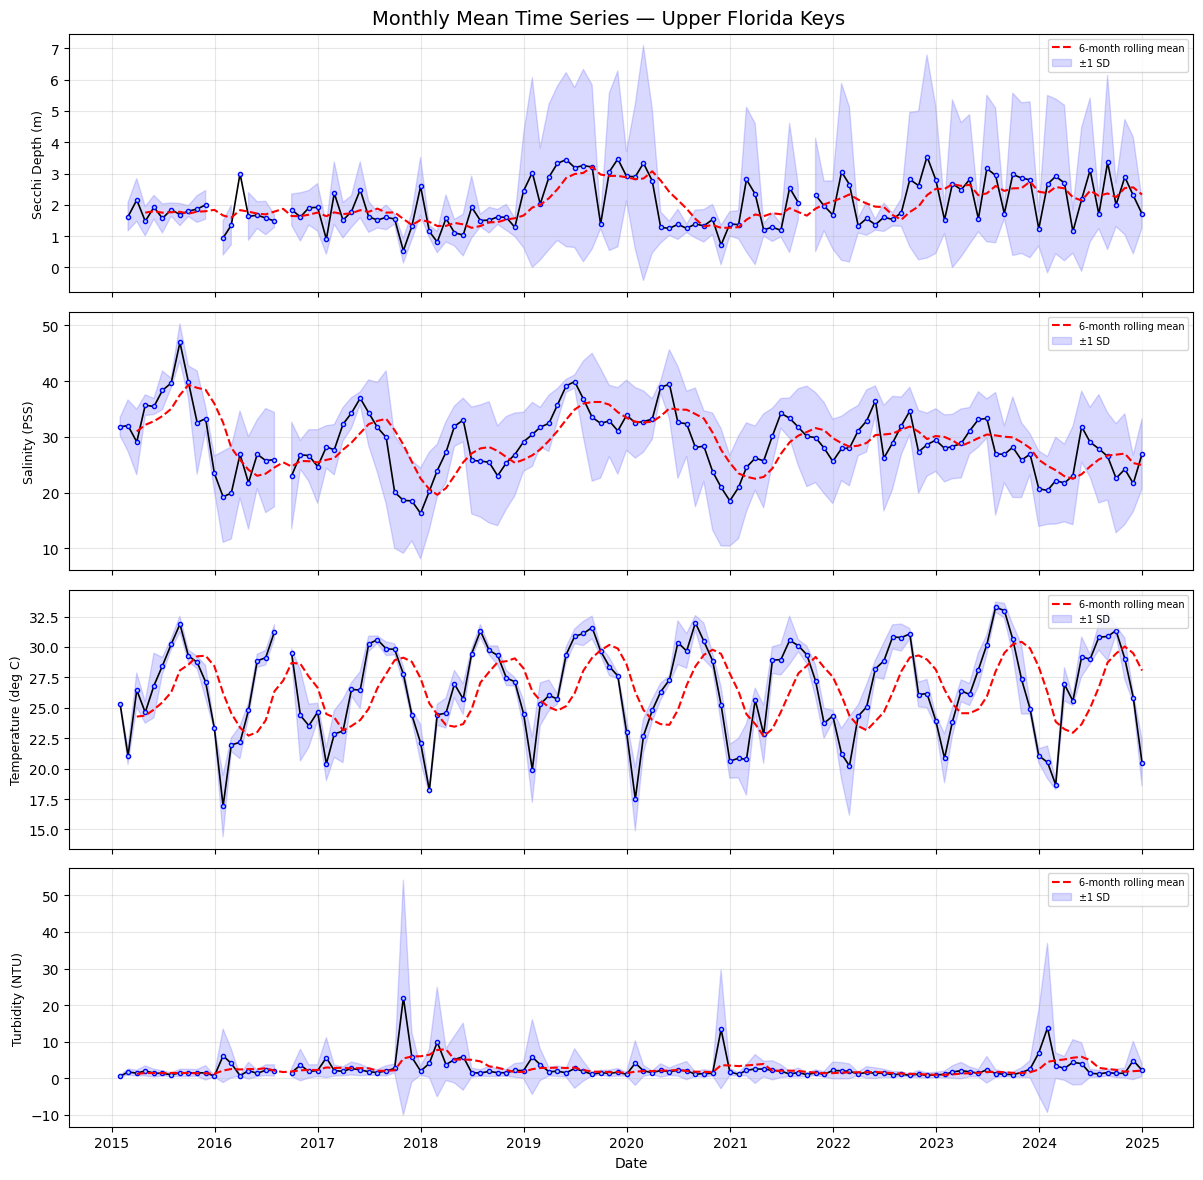

In [43]:
fig, axes = plt.subplots(len(param_cols), 1, figsize=(12, 3 * len(param_cols)), sharex=True)

for i, col in enumerate(param_cols):
    # Compute mean and std from the same resampling operation
    monthly_mean = wq_gdf[col].resample("ME").mean()
    monthly_std  = wq_gdf[col].resample("ME").std()

    axes[i].plot(monthly_mean.index, monthly_mean, linewidth=1.2, 
                 color='black', marker='o', markersize=3, markerfacecolor='lightblue',
                 markeredgecolor='blue')
    axes[i].set_ylabel(col, fontsize=9)
    axes[i].grid(True, alpha=0.3)
    
    # Add a rolling 6-month mean to show trend
    rolling = monthly_mean.rolling(window=6, min_periods=3).mean()
    axes[i].plot(monthly_mean.index, rolling, linewidth=1.5, 
                 color='red', linestyle='--', label='6-month rolling mean')
    
    # Shade ± 1 standard deviation band
    axes[i].fill_between(monthly_mean.index, 
                          monthly_mean - monthly_std, 
                          monthly_mean + monthly_std,
                          alpha=0.15, color='blue', label='±1 SD')
    
    axes[i].legend(fontsize=7, loc='upper right')

axes[-1].set_xlabel("Date")
fig.suptitle("Monthly Mean Time Series — Upper Florida Keys", fontsize=14)
plt.tight_layout()
plt.savefig("time_series.png", dpi=150)
plt.show()

#### Dual Time Series

Secchi Depth (WQ) + NDWI (Spectral) — water clarity \
Secchi Depth (WQ) + NDAVI (Spectral) — seagrass response

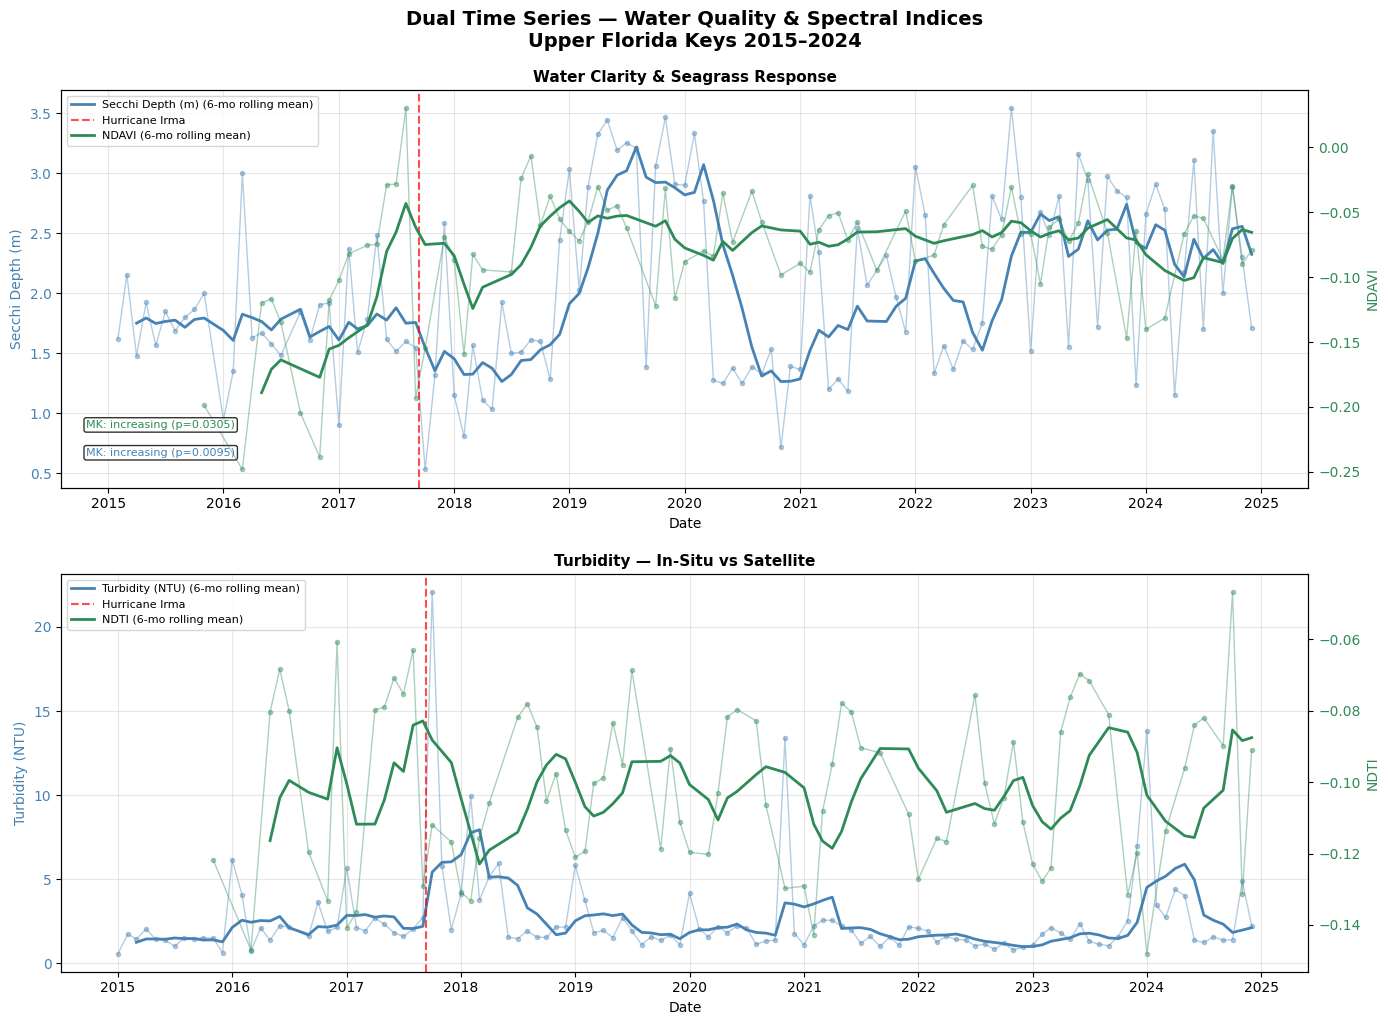

In [45]:
dual_pairs = [
    ("Secchi Depth (m)", "NDAVI", "Water Clarity & Seagrass Response"),
    ("Turbidity (NTU)",  "NDTI",  "Turbidity — In-Situ vs Satellite"),
]

fig, axes = plt.subplots(len(dual_pairs), 1, figsize=(14, 5 * len(dual_pairs)))

for i, (wq_col, spec_col, title) in enumerate(dual_pairs):
    ax1 = axes[i]
    ax2 = ax1.twinx()

    # WQ — left axis
    wq_series  = df_wq_monthly[wq_col].dropna()
    wq_rolling = wq_series.rolling(6, min_periods=3).mean()

    ax1.plot(wq_series.index, wq_series, color="steelblue",
             linewidth=1, alpha=0.4, marker="o", markersize=3)
    ax1.plot(wq_rolling.index, wq_rolling, color="steelblue",
             linewidth=2, label=f"{wq_col} (6-mo rolling mean)")
    ax1.set_ylabel(wq_col, color="steelblue", fontsize=10)
    ax1.tick_params(axis="y", labelcolor="steelblue")

    # Spectral — right axis
    spec_series  = df_spec_monthly[spec_col].dropna()
    spec_rolling = spec_series.rolling(6, min_periods=3).mean()

    ax2.plot(spec_series.index, spec_series, color="seagreen",
             linewidth=1, alpha=0.4, marker="o", markersize=3)
    ax2.plot(spec_rolling.index, spec_rolling, color="seagreen",
             linewidth=2, label=f"{spec_col} (6-mo rolling mean)")
    ax2.set_ylabel(spec_col, color="seagreen", fontsize=10)
    ax2.tick_params(axis="y", labelcolor="seagreen")

    # Hurricane Irma marker
    ax1.axvline(pd.Timestamp("2017-09-10"), color="red", linewidth=1.5,
                linestyle="--", alpha=0.7, label="Hurricane Irma")

    # Trend annotations for significant results
    mk_wq   = df_mk_wq[df_mk_wq["Parameter"] == wq_col]
    mk_spec = df_mk_spec[df_mk_spec["Index"] == spec_col]

    if not mk_wq.empty and mk_wq.iloc[0]["Significant"]:
        ax1.annotate(f"MK: {mk_wq.iloc[0]['Trend']} (p={mk_wq.iloc[0]['p-value']})",
                    xy=(0.02, 0.08), xycoords="axes fraction",
                    fontsize=8, color="steelblue",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))

    if not mk_spec.empty and mk_spec.iloc[0]["Significant"]:
        ax2.annotate(f"MK: {mk_spec.iloc[0]['Trend']} (p={mk_spec.iloc[0]['p-value']})",
                    xy=(0.02, 0.15), xycoords="axes fraction",
                    fontsize=8, color="seagreen",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))

    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2,
               loc="upper left", fontsize=8)

    ax1.set_title(title, fontsize=11, fontweight="bold")
    ax1.grid(True, alpha=0.3)
    ax1.set_xlabel("Date")

fig.suptitle("Dual Time Series — Water Quality & Spectral Indices\nUpper Florida Keys 2015–2024",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(top=0.94)
plt.savefig("dual_time_series.png", dpi=150, bbox_inches="tight")
plt.show()

#### Water quality and spectral index correlation by year

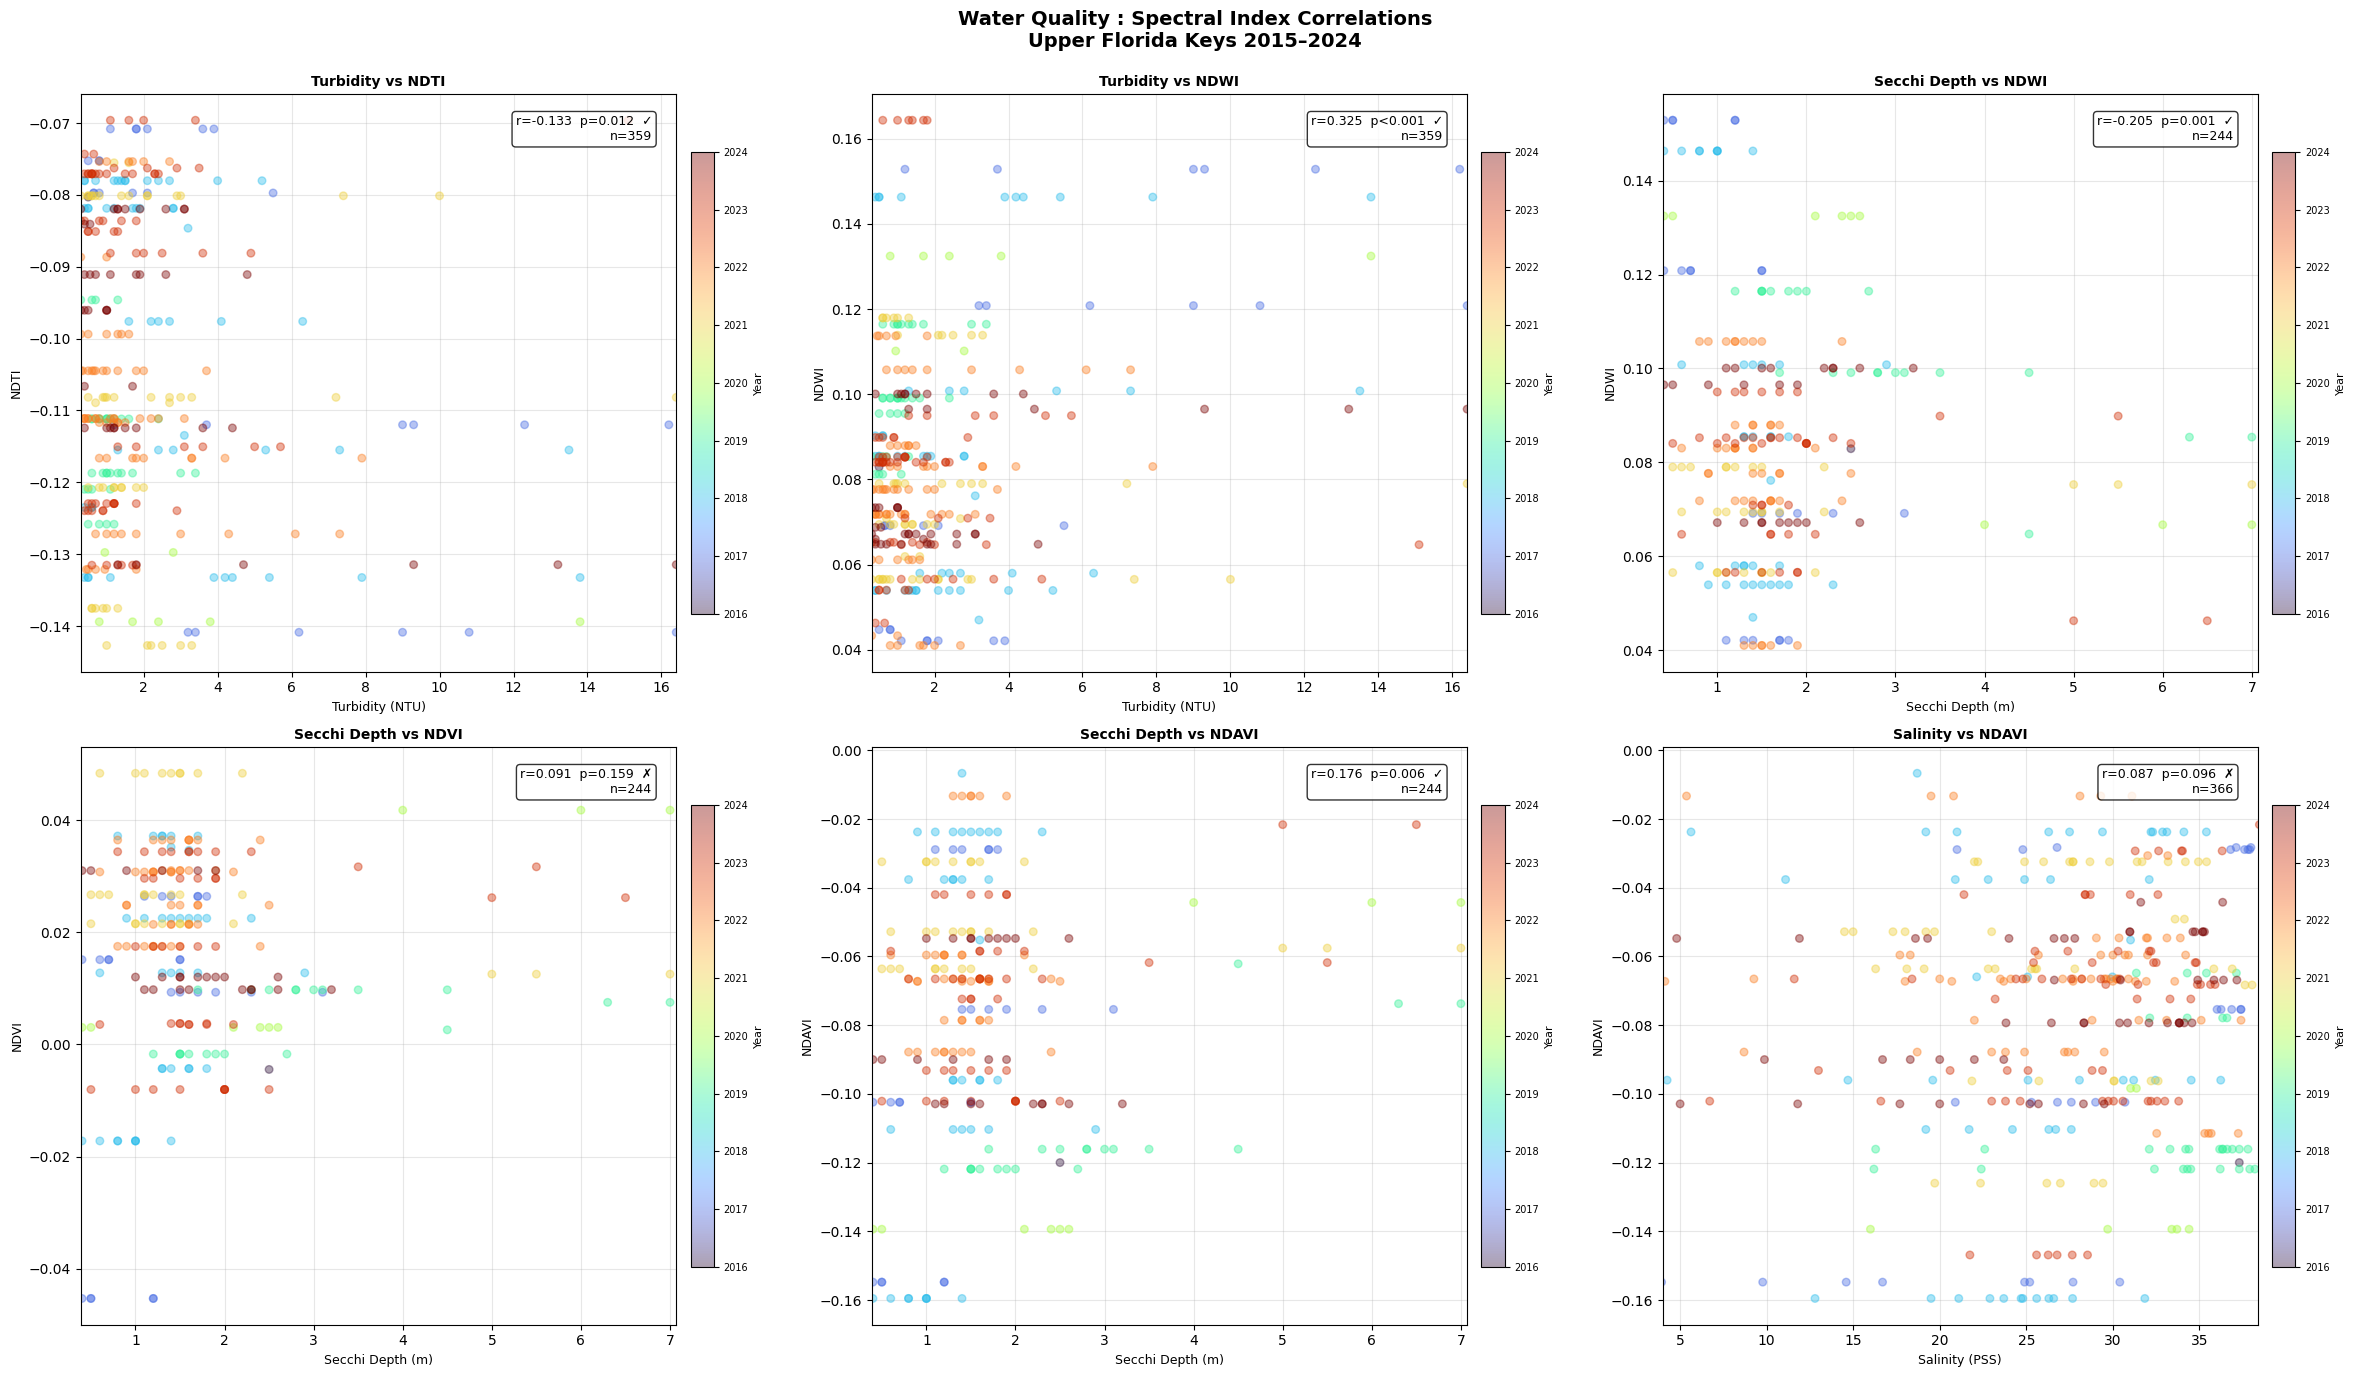

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes = axes.flatten()

for i, (wq_col, spec_col, label) in enumerate(pair_cols):
    ax = axes[i]
    paired = df_matched[[wq_col, spec_col]].dropna()
    x = paired[wq_col]
    y = paired[spec_col]

    # Compute regression INSIDE the loop
    slope, intercept, r, p, _ = stats.linregress(x, y)
    x_start, x_end = x.min(), x.max()
    y_start = slope * x_start + intercept
    y_end   = slope * x_end   + intercept

    # Scatter colored by year
    years = paired.index.year
    scatter = ax.scatter(x, y, c=years, cmap="turbo",
                        alpha=0.4, s=30, zorder=2)

    # Only draw arrow if significant
    if p < 0.05:
        ax.annotate("",
                    xy=(x_end, y_end),
                    xytext=(x_start, y_start),
                    arrowprops=dict(arrowstyle="-|>", color="black", lw=1.0),
                    zorder=3)

    # Correlation annotation
    p_str = "p<0.001" if p < 0.001 else f"p={p:.3f}"
    sig_str = "✓" if p < 0.05 else "✗"
    ax.annotate(f"r={r:.3f}  {p_str}  {sig_str}\nn={len(paired)}",
                xy=(0.96, 0.92), xycoords="axes fraction",
                fontsize=9, color="black",
                ha="right",
                bbox=dict(boxstyle="round,pad=0.3",
                         facecolor="white", alpha=0.8))

    ax.set_xlabel(wq_col, fontsize=9)
    ax.set_ylabel(spec_col, fontsize=9)
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_xlim(x.quantile(0.02), x.quantile(0.98))
    ax.grid(True, alpha=0.3)

    cbar = fig.colorbar(scatter, ax=ax, pad=0.02, shrink=0.8)
    cbar.set_label("Year", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Water Quality : Spectral Index Correlations\nUpper Florida Keys 2015–2024",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig("wq_spectral_correlations.png", dpi=150, bbox_inches="tight")
plt.show()